# SBERT & NCF Feasibility Test (Subset)

## Purpose:  
Run a quick feasibility test of:
- Sentence-BERT content-based similarity on a small data subset
- Neural Collaborative Filtering (NCF) on a small subset of users and bundles

## Objectives/Goals:  
- Ensure both SBERT and NCF run without memory/time issues  
- Confirm that similarity and collaborative learning produce reasonable outputs

As suggested from the preliminary report’s feedback **prove feasibility by getting SBERT/NCF running on a small subset**. Two experiments were conducted in this Notebook Experiments file

In [1]:
# Setup & Imports
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sentence_transformers import SentenceTransformer, util
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from torch import nn

## 1. Load and Subset Data
- Load the cleaned merged dataset (`merged_cleaned_data.csv`)
- Load lecture metadata (`cleaned_lectures.csv`)
- Subset to the first 10 users and first 20 bundles for faster testing

In [2]:
# Load and subset data
merged_df = pd.read_csv('../data/cleaned/merged_cleaned_data.csv')
lectures_df = pd.read_csv('../data/cleaned/cleaned_lectures.csv')

# Pick a small subset of users
subset_users = merged_df['user_id'].unique()[:10]
subset_df = merged_df[merged_df['user_id'].isin(subset_users)]

# Pick a small subset of items
subset_items = subset_df['bundle_id'].unique()[:20]
subset_df = subset_df[subset_df['bundle_id'].isin(subset_items)]

## 2. SBERT Content-Based Similarity (First Test)
- I aim to check whether SBERT can generate embeddings and produce cosine similarity values.
- For speed, we do not train - only compute similarity.

Cosine Similarity (First 5x5):
tensor([[0.]])


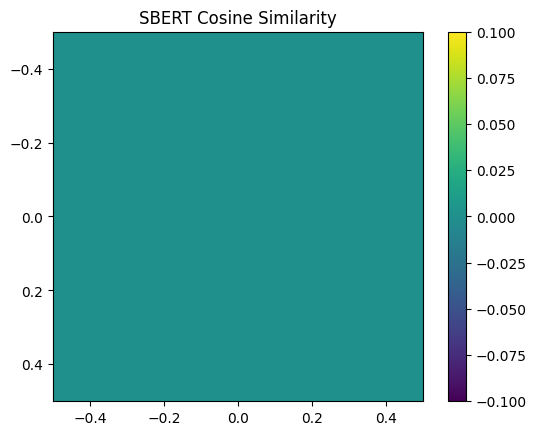

In [3]:
# Create pseudo-text combining lecture part and tags
lectures_df["pseudo_text"] = lectures_df.apply(
    lambda row: f"Part {row['part']} | Tags: {row['tags']}", axis=1
)

# Select subset of lecture IDs and extract corresponding pseudo-texts
subset_ids = [f"l{i}" for i in subset_items]
sample_texts = lectures_df[lectures_df['lecture_id'].isin(subset_ids)]['pseudo_text'].fillna("").tolist()

# Load pre-trained SBERT model
sbert = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings for the pseudo-texts
embeddings = sbert.encode(sample_texts, convert_to_tensor=True)

# Compute cosine similarity between all embeddings
similarity_matrix = util.pytorch_cos_sim(embeddings, embeddings)

# Display top-left 5x5 block of similarity matrix
print("Cosine Similarity (First 5x5):")
print(similarity_matrix[:5, :5])

# Visualize similarity matrix using a heatmap
plt.imshow(similarity_matrix.cpu().numpy(), cmap="viridis")
plt.colorbar()
plt.title("SBERT Cosine Similarity")
plt.show()

## 3. NCF Collaborative Filtering - Data Preparation
- Map `user_id` and `bundle_id` to integer indices
- Add an `is_correct` → `label` column for binary relevance
- Split into train and validation sets

In [4]:
print("\n--- NCF Collaborative Filtering Feasibility ---")

# Create mappings from user and item IDs to integer indices
user_map = {uid: i for i, uid in enumerate(subset_df['user_id'].unique())}
item_map = {bid: i for i, bid in enumerate(subset_df['bundle_id'].unique())}

# Map original IDs to indices in the dataframe
subset_df['user_idx'] = subset_df['user_id'].map(user_map)
subset_df['item_idx'] = subset_df['bundle_id'].map(item_map)

# Convert correctness flag to float label for binary relevance
subset_df['label'] = subset_df['is_correct'].astype(float)

# Prepare input features and target labels
X = subset_df[['user_idx', 'item_idx']].values
y = subset_df['label'].values

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


--- NCF Collaborative Filtering Feasibility ---


## 4. NCF Model Definition
A small Neural Collaborative Filtering (NCF) network:
- Embedding layers for users and items
- Fully connected layers to predict interaction probability

In [5]:
# NCF (Neural Collaborative Filtering) model definition
class NCF(nn.Module):
    def __init__(self, num_users, num_items, n_factors=8):
        super().__init__()
        # Embedding layers for users and items
        self.user_emb = nn.Embedding(num_users, n_factors)
        self.item_emb = nn.Embedding(num_items, n_factors)
        # Fully connected layers for interaction modeling
        self.fc1 = nn.Linear(n_factors * 2, 32)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, users, items):
        # Look up embeddings for users and items
        u = self.user_emb(users)
        i = self.item_emb(items)
        # Concatenate embeddings and pass through network
        x = torch.cat([u, i], dim=-1)
        x = torch.relu(self.fc1(x))
        # Output predicted relevance score (between 0 and 1)
        return torch.sigmoid(self.fc2(x)).squeeze()

## 5. NCF Training Loop
- Binary cross-entropy loss
- Adam optimizer
- Train for 10 epochs
- Track and plot training loss

Epoch 1: Loss = 0.6871
Epoch 2: Loss = 0.6564
Epoch 3: Loss = 0.6300
Epoch 4: Loss = 0.6062
Epoch 5: Loss = 0.5844
Epoch 6: Loss = 0.5635
Epoch 7: Loss = 0.5436
Epoch 8: Loss = 0.5246
Epoch 9: Loss = 0.5064
Epoch 10: Loss = 0.4896


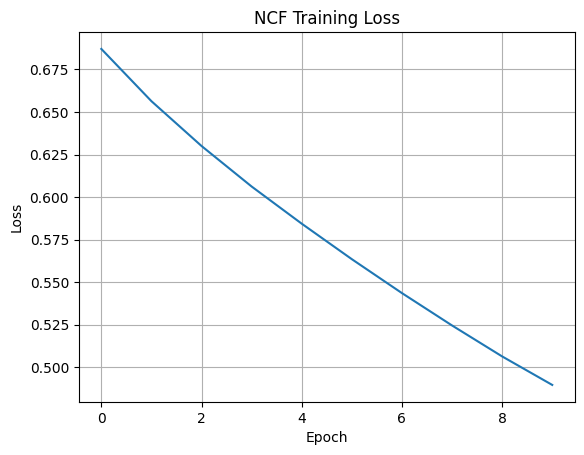

In [6]:
# Initialize NCF model with number of users and items
model = NCF(len(user_map), len(item_map))

# Set up optimizer and binary cross-entropy loss function
opt = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.BCELoss()

# Convert training data to PyTorch tensors
train_users = torch.tensor(X_train[:,0], dtype=torch.long)
train_items = torch.tensor(X_train[:,1], dtype=torch.long)
train_labels = torch.tensor(y_train, dtype=torch.float32)

# Convert validation data to PyTorch tensors
val_users = torch.tensor(X_val[:,0], dtype=torch.long)
val_items = torch.tensor(X_val[:,1], dtype=torch.long)
val_labels = torch.tensor(y_val, dtype=torch.float32)

# Train the model for 10 epochs and record loss
losses = []
for epoch in range(10):
    model.train()
    opt.zero_grad()
    preds = model(train_users, train_items)  # Forward pass
    loss = loss_fn(preds, train_labels) # Compute loss
    loss.backward() # Backpropagation
    opt.step() # Update weights
    losses.append(loss.item()) # Store loss value
    print(f"Epoch {epoch+1}: Loss = {loss.item():.4f}")

# Plot training loss over epochs
plt.plot(losses)
plt.title("NCF Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

## 6. Evaluation - RMSE on Validation Set
I check predictive accuracy using RMSE.

In [7]:
# Set model to evaluation mode
model.eval()

# Disable gradient computation for evaluation
with torch.no_grad():
    # Generate predictions for validation set
    val_preds = model(val_users, val_items)
    # Calculate RMSE between predictions and true labels
    rmse = torch.sqrt(((val_preds - val_labels) ** 2).mean()).item()
    print(f"Validation RMSE: {rmse:.4f}")

Validation RMSE: 0.5314


## 7. Observations
- Loss decreased steadily over 10 epochs, indicating the model is learning.  
- RMSE ~0.53 on a very small subset - this is not meaningful for production, but shows feasibility.  
- With the full dataset, results may differ significantly due to more data diversity.  